In [1]:
#데이터 불러오기
import pandas as pd
d=pd.read_csv('bestSelling_games.csv')

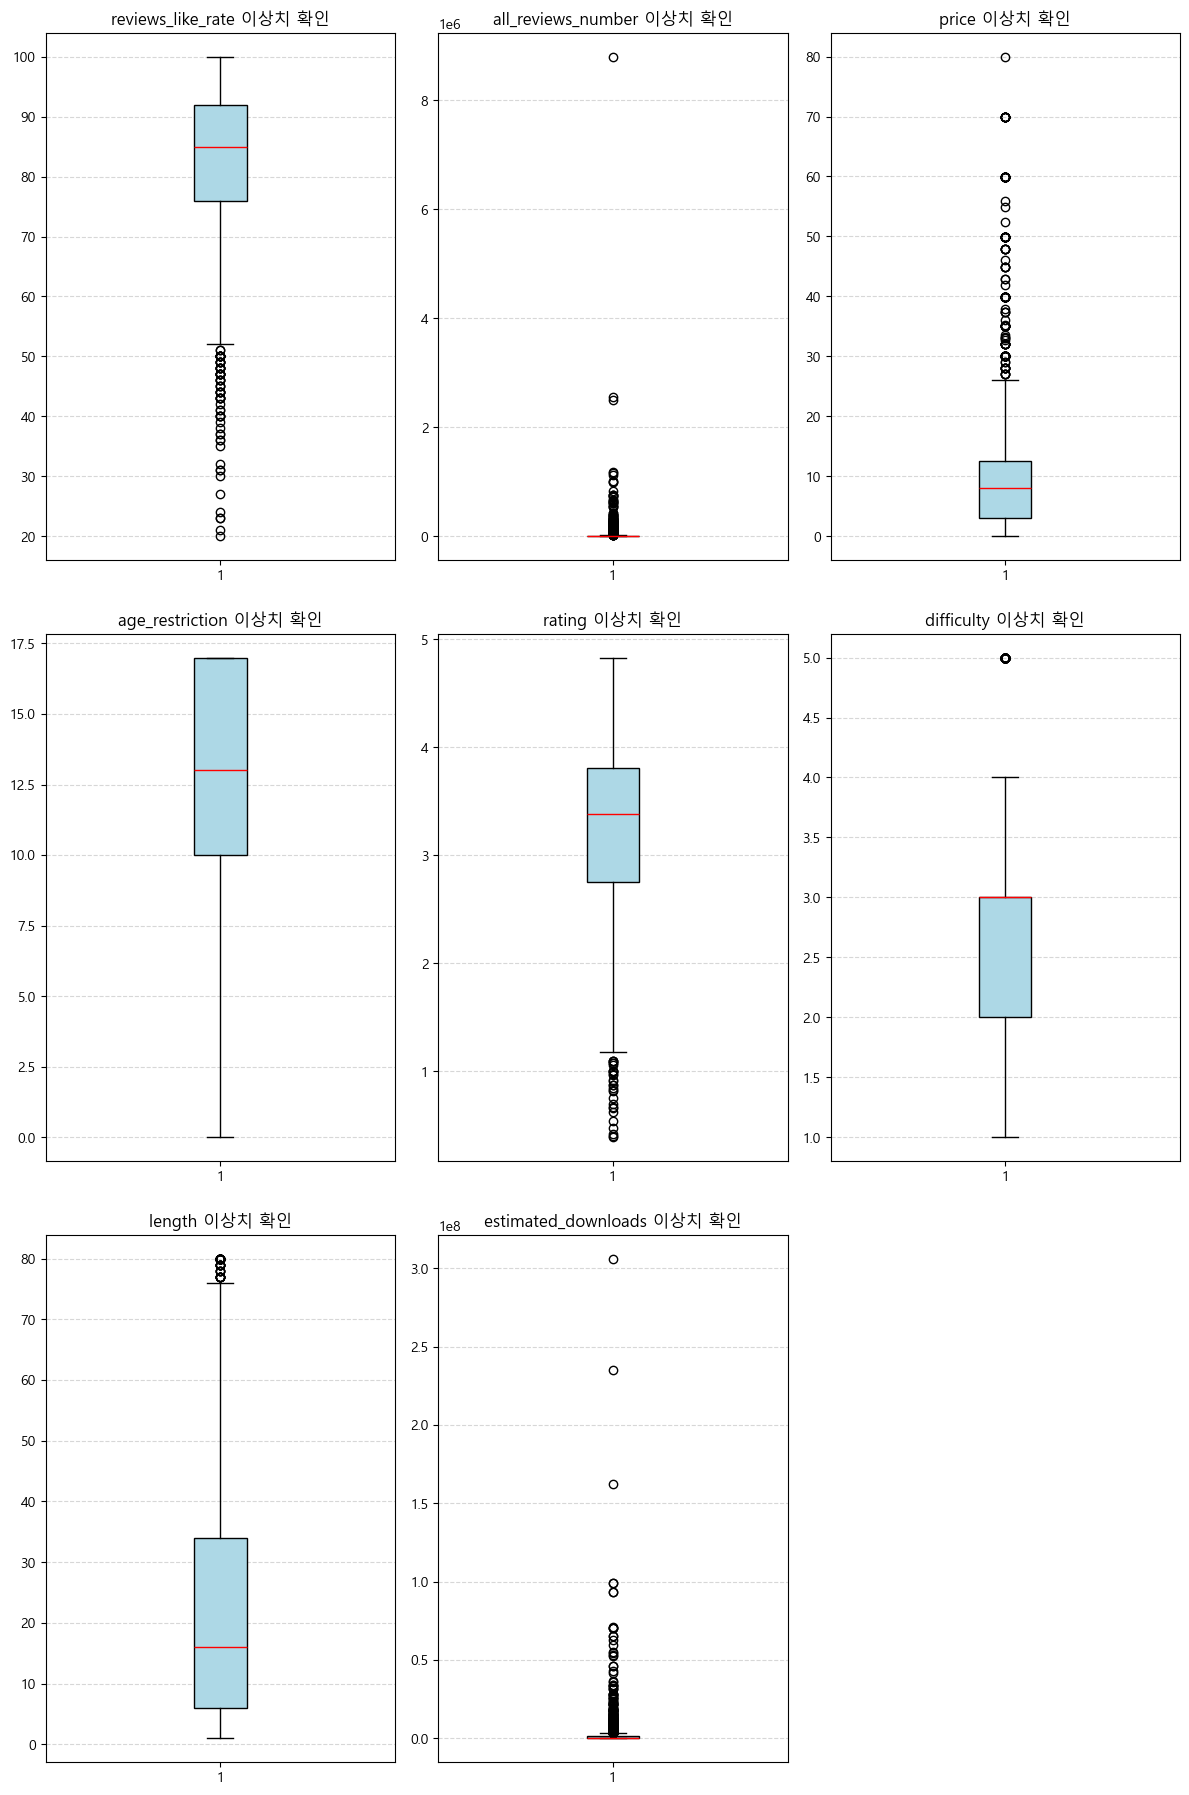

In [2]:
#이상치 확인
import matplotlib.pyplot as plt
from matplotlib import rc
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
numeric_cols=d.select_dtypes(include=['number']).columns
n_cols = 3
n_rows = len(numeric_cols)
plt.figure(figsize=(12, n_rows * 6))

for i, col in enumerate(numeric_cols):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    
    box = ax.boxplot(d[col].dropna(), patch_artist=True)
    
    box['boxes'][0].set_facecolor('lightblue') # 박스 색상
    box['medians'][0].set_color('red')         # 중앙값 선 색상 (빨간색)
    
    ax.set_title(f'{col} 이상치 확인', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [3]:
#총 리뷰 수(all_reviews_number)와 판매량(estimated_downloads) 이상치 처리 필요 확인
#대부분의 게임은 총 리뷰수와 판매량이 매우 낮은 쪽으로 치우쳐져 있고 
#소수의 게임들만이 높은 리뷰수와 판매량을 보임
#해당 속성값을 사이의 격차를 줄이고 이상치의 영향력을 줄이기 위해 로그 변환
import numpy as np
d['log_reviews']=np.log1p(d['all_reviews_number'])
d['log_downloads']=np.log1p(d['estimated_downloads'])

d[['all_reviews_number','log_reviews','estimated_downloads','log_downloads']]

,all_reviews_number,log_reviews,estimated_downloads,log_downloads
0,8803754,15.990689,306170000,19.539651
1,2554482,14.753360,162350000,18.905265
2,53426,10.886072,840000,13.641158
3,45424,10.723818,2000000,14.508658
4,672140,13.418223,21610000,16.888667
...,...,...,...,...
2375,147,4.997212,221000,12.305923
2376,65,4.189655,2700,7.901377
2377,416,6.033086,47500,10.768506
2378,498,6.212606,79000,11.277216


In [4]:
#데이터에서 게임을 출시년도를 기준으로 분석하기 위해 출시일에서 출시년도 추출
d['year']=d['release_date'].astype(str).str.strip().str[-4:].astype('Int64')

In [5]:
#각 게임에서 지원하는 언어의 개수를 새로운 변수로 만들고자 함
d['language_count']=d['supported_languages'].str.split(',').str.len()
d['language_count']=d['language_count'].fillna(0).astype(int)

In [6]:
#각 게임에서 지원하는 장르의 수를 새로운 변수로 만들고자 함
d['genre_count'] = d['user_defined_tags'].str.split(',').str.len()

In [8]:
d[['release_date','year','supported_languages','language_count','user_defined_tags','genre_count']].head()

,release_date,year,supported_languages,language_count,user_defined_tags,genre_count
0,"21 Aug, 2012",2012,"English, Czech, Danish, Dutch, Finnish, French...",29,"FPS, Action, Tactical",3
1,"21 Dec, 2017",2017,"English, Korean, Simplified Chinese, French, G...",17,"Survival, Shooter, Action, Tactical",4
2,"30 May, 2025",2025,"English, Japanese, French, Italian, German, Sp...",15,"Souls-like, Open World, Fantasy, RPG",4
3,"28 Mar, 2023",2023,"English, Italian, Spanish - Spain, Czech, Dutc...",25,"Story Rich, Shooter, Survival, Horror",4
4,"5 Dec, 2019",2019,"English, French, Italian, German, Spanish - Sp...",13,"Open World, Story Rich, Adventure, Realistic, ...",6


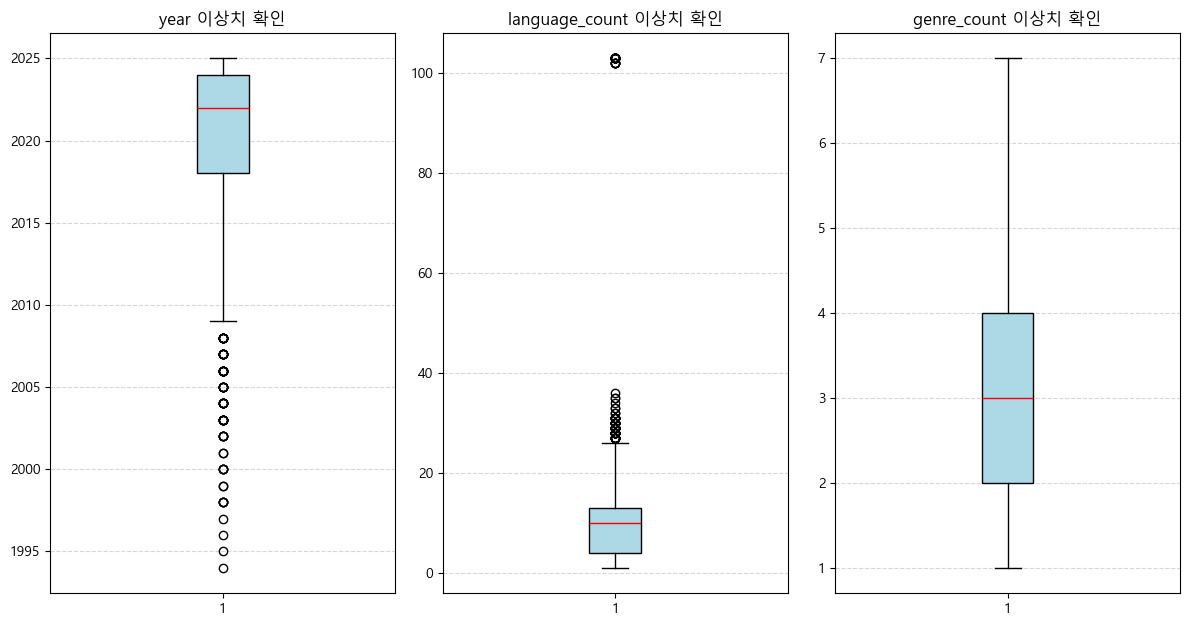

In [9]:
#새로 만든 변수들의 이상치 확인
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, n_rows * 6))

for i, col in enumerate(['year','language_count','genre_count']):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    
    box = ax.boxplot(d[col].dropna(), patch_artist=True)
    
    box['boxes'][0].set_facecolor('lightblue') # 박스 색상
    box['medians'][0].set_color('red')         # 중앙값 선 색상 (빨간색)
    
    ax.set_title(f'{col} 이상치 확인', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
d[d['language_count'] > 40][['game_name', 'language_count', 'user_defined_tags']]

,game_name,language_count,user_defined_tags
865,Zup! S,103,"Puzzle, 2D"
1195,Barro F22,102,"Driving, Sports, Simulation"
1393,Zup! 8,103,"Puzzle, 2D"
1483,aMAZE Frozen,103,"Strategy, Puzzle, 2D"
1613,Zup! F,103,"Puzzle, 2D"
1811,Only Up !,103,"Adventure, Strategy, Platformer"
1824,FALCO AXE,103,"Adventure, Action, Combat"
1859,Dollar,103,"Management, 2D"
1912,From The Past,103,"Horror, Simulation, Adventure, Realistic"
1948,Zup! X,103,"Puzzle, 2D, Platformer"


In [12]:
#지원 언의 수 경우 소수의 게임이 103개의 언어를 지원하고 있음
#해당 게임들의 경우 퍼즐, 캐주얼 게임 이거나 텍스트 많이 등장하지 않는 게임들 인것을 확인
#마치 테트리스가 한국어를 지원하지 않더라도 플레이 할 수 있는 것처럼 
#해당 게임들의 경우 언어적 의사소통 이 필요하지 않기에 여러 언어를 지원하는 것이 의미가 없기에 결측치로 처리
d['language_count_dd'] = d['language_count'].copy()
d.loc[d['language_count_dd'] > 40, 'language_count_dd'] = np.nan
d[d['language_count'] > 40][['language_count','language_count_dd']].head()

,language_count,language_count_dd
865,103,NaN
1195,102,NaN
1393,103,NaN
1483,103,NaN
1613,103,NaN


In [20]:
#장르별 게임수
#사용자 지정 태그를 통해 각 게임의 장르를 담은 변수를
#만들고 역으로 각 장르별 게임수를 구함
d['genre_list'] = d['user_defined_tags'].str.split(',')
d_exploded=d.explode('genre_list')
d_exploded['genre_list'] = d_exploded['genre_list'].str.strip()
d_exploded=d_exploded[d_exploded['genre_list']!='']
genre_stats = d_exploded.groupby('genre_list')['game_name'].agg(['count'])
genre_stats

,count
genre_list,
2.5D,16
2D,308
Action,730
Adventure,523
Anime,129
Automation,36
Building,176
CRPG,11
Card Game,48


In [21]:
d.head()

,game_name,reviews_like_rate,all_reviews_number,release_date,developer,user_defined_tags,supported_os,supported_languages,price,other_features,...,difficulty,length,estimated_downloads,log_reviews,log_downloads,year,language_count,genre_count,language_count_dd,genre_list
0,Counter-Strike 2,86,8803754,"21 Aug, 2012",Valve,"FPS, Action, Tactical","win, linux","English, Czech, Danish, Dutch, Finnish, French...",0.00,"Cross-Platform Multiplayer, Steam Trading Card...",...,4,80,306170000,15.990689,19.539651,2012,29,3,29.0,"[FPS, Action, Tactical]"
1,PUBG: BATTLEGROUNDS,59,2554482,"21 Dec, 2017",PUBG Corporation,"Survival, Shooter, Action, Tactical",win,"English, Korean, Simplified Chinese, French, G...",0.00,"Online PvP, Stats, Remote Play on Phone, Remot...",...,4,73,162350000,14.753360,18.905265,2017,17,4,17.0,"[Survival, Shooter, Action, Tactical]"
2,ELDEN RING NIGHTREIGN,77,53426,"30 May, 2025","FromSoftware, Inc.","Souls-like, Open World, Fantasy, RPG",win,"English, Japanese, French, Italian, German, Sp...",25.99,"Single-player, Online Co-op, Steam Achievement...",...,4,50,840000,10.886072,13.641158,2025,15,4,15.0,"[Souls-like, Open World, Fantasy, RPG]"
3,The Last of Us™ Part I,79,45424,"28 Mar, 2023",Naughty Dog LLC,"Story Rich, Shooter, Survival, Horror",win,"English, Italian, Spanish - Spain, Czech, Dutc...",59.99,"Single-player, Steam Achievements, Steam Tradi...",...,3,24,2000000,10.723818,14.508658,2023,25,4,25.0,"[Story Rich, Shooter, Survival, Horror]"
4,Red Dead Redemption 2,92,672140,"5 Dec, 2019",Rockstar Games,"Open World, Story Rich, Adventure, Realistic, ...",win,"English, French, Italian, German, Spanish - Sp...",59.99,"Single-player, Online PvP, Online Co-op, Steam...",...,3,80,21610000,13.418223,16.888667,2019,13,6,13.0,"[Open World, Story Rich, Adventure, Realist..."


In [22]:
d.to_csv('2주차_data.csv', index=False)